# Intuition-building exercises

Each exercise has a **prediction** prompt. Write your guess before running the code cell — the goal is to calibrate your mental model of what persistence diagrams encode.



In [1]:
# setup imports
import matplotlib.pyplot as plt
import numpy as np
from gtda.homology import VietorisRipsPersistence
from gtda.plotting import plot_diagram



## Exercise 1: Gap size → H1 birth time

We take the unit circle and vary the removed arc: 30°, 60°, 90°, 120°.

**Predict before running:** As the gap gets larger, what happens to the H1 feature's birth time? Does it shift right (born later), shrink in persistence, or disappear entirely at some gap size?

**My prediction:** As the gap gets larger, the H1 feature's birth time should shift right and its persistence should decrease. I presume if the gap is greater than (maybe) 180°, we might not even detect an H1 feature.


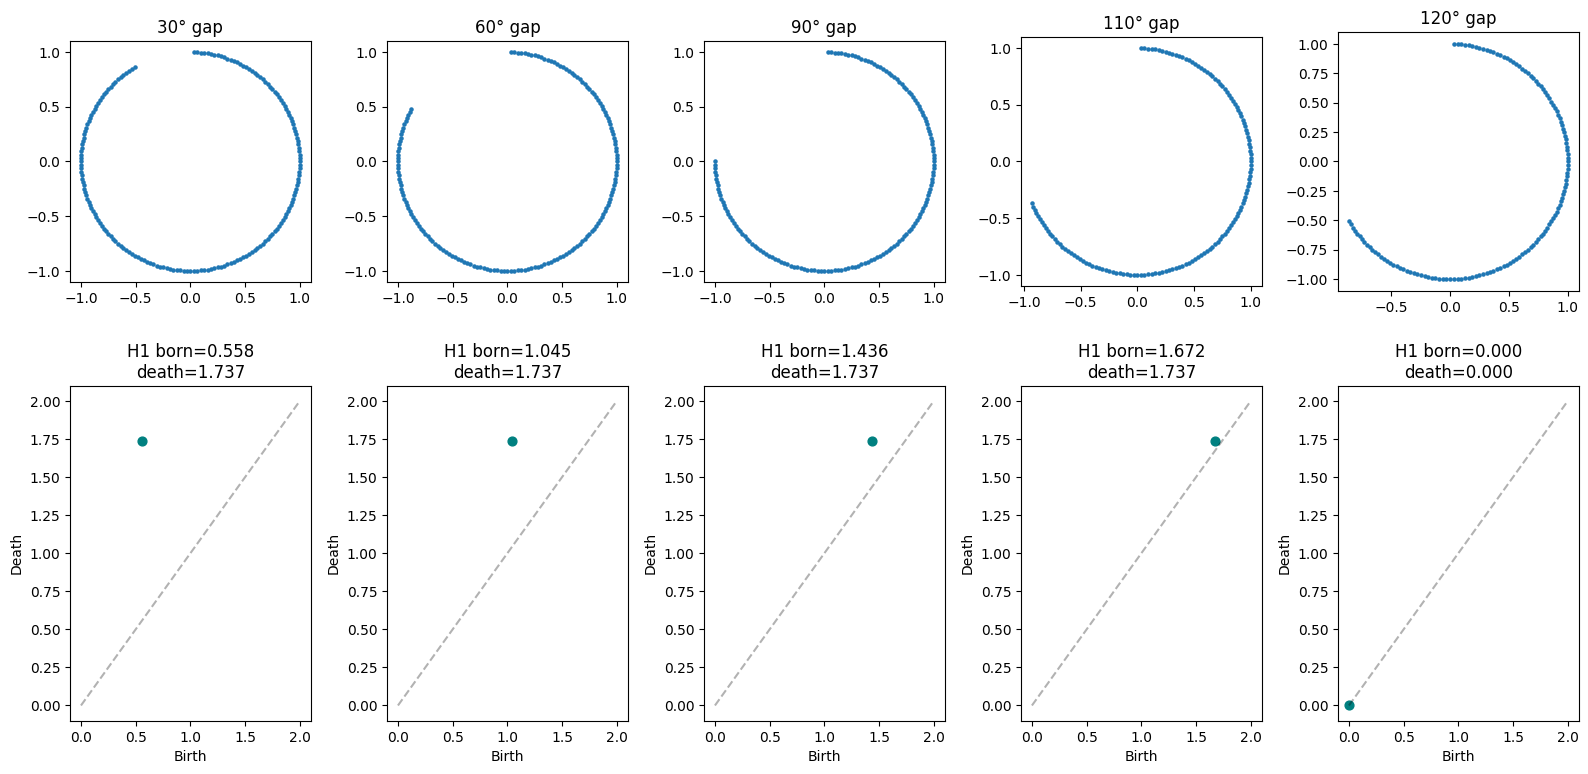

In [2]:

gaps_deg = [30, 60, 90, 110, 120]
n = 200
theta = np.linspace(0, 2 * np.pi, n, endpoint=False)
# (cos(θ), sin(θ)) for θ in [0, 2π/n, 4π/n, ..., 2π(n-1)/n]
full = np.stack([np.cos(theta), np.sin(theta)], axis=1)

vr = VietorisRipsPersistence(homology_dimensions=[0, 1])

fig, axes = plt.subplots(2, len(gaps_deg), figsize=(16, 8))

for i, gap in enumerate(gaps_deg):
    gap_rad = np.radians(gap)
    mask = ~((theta > np.pi/2) & (theta < np.pi/2 + gap_rad))
    pts = full[mask]

    # Plot point cloud
    axes[0, i].scatter(pts[:, 0], pts[:, 1], s=5)
    axes[0, i].set_title(f"{gap}° gap")
    axes[0, i].set_aspect("equal")

    # Compute persistence
    diag = vr.fit_transform(pts[None, ...])[0]

    # Plot H1 features only
    h1 = diag[diag[:, 2] == 1]
    if len(h1) > 0:
        persistence = h1[:, 1] - h1[:, 0]
        max_idx = persistence.argmax()
        axes[1, i].scatter(h1[:, 0], h1[:, 1], c="teal", s=40)
        axes[1, i].set_title(f"H1 born={h1[max_idx, 0]:.3f}\ndeath={h1[max_idx, 1]:.3f}")
    else:
        axes[1, i].set_title("No H1 features")

    # Diagonal reference
    lim = max(axes[1, i].get_xlim()[1], axes[1, i].get_ylim()[1])
    axes[1, i].plot([0, 2], [0, 2], "k--", alpha=0.3)
    axes[1, i].set_xlabel("Birth")
    axes[1, i].set_ylabel("Death")

plt.tight_layout()
plt.show()



## Exercise 2: Two clusters, varying separation

Two Gaussian blobs (100 pts each) in 2D with separation 10, 5, and 2.

**Predict before running:** The H0 diagram should show two components merging into one. At what point does the "second component" feature die? How does that death time relate to the cluster separation? What happens when separation=2 and the clusters overlap?

**My prediction:** We should see two H0 dots and the vertical distance between them is proportional to the separation. When separation=2 and the cluster overlap we should only see 1 H0 feature.


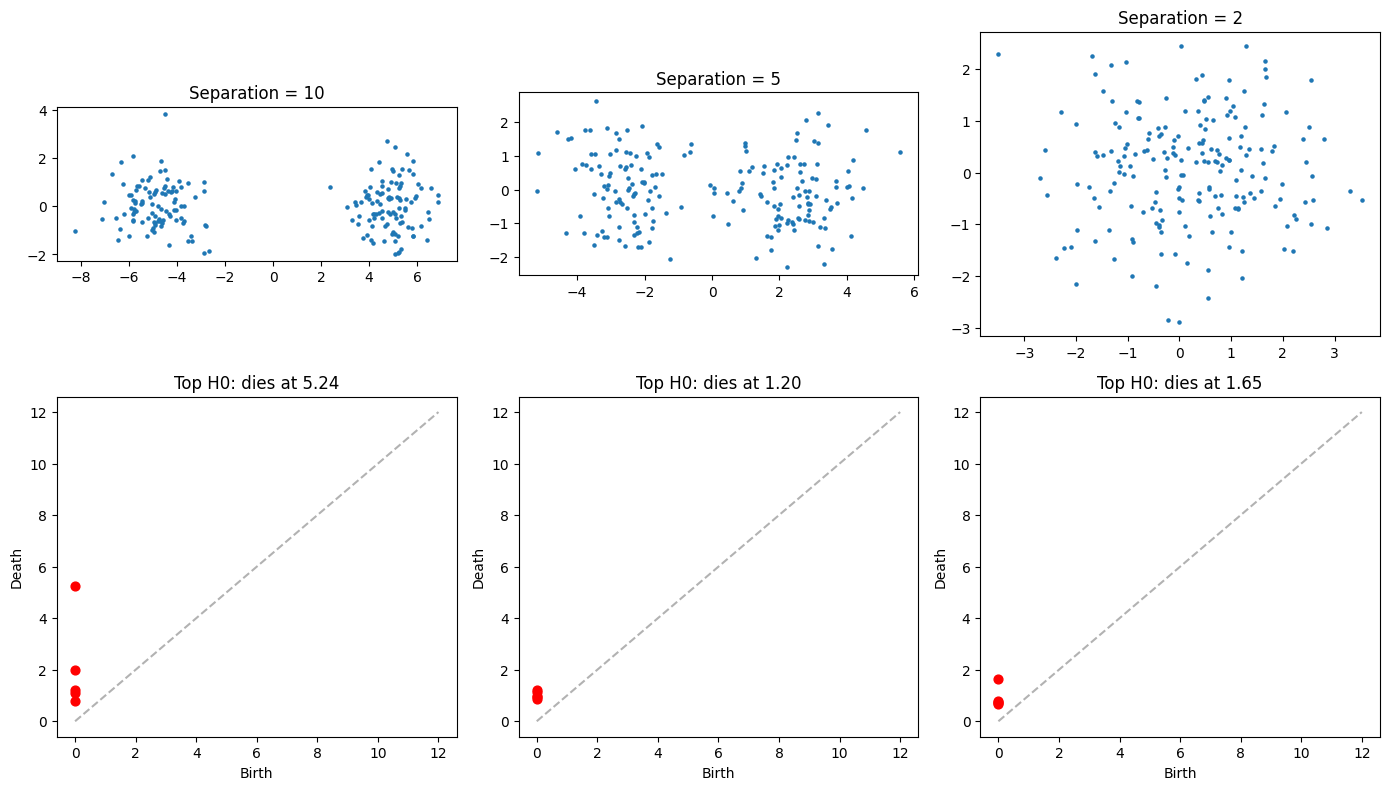

In [3]:

np.random.seed(42)
separations = [10, 5, 2]
fig, axes = plt.subplots(2, len(separations), figsize=(14, 8))

for i, sep in enumerate(separations):
    cluster_a = np.random.randn(100, 2) + np.array([sep/2, 0])
    cluster_b = np.random.randn(100, 2) - np.array([sep/2, 0])
    pts = np.vstack([cluster_a, cluster_b])

    axes[0, i].scatter(pts[:, 0], pts[:, 1], s=5)
    axes[0, i].set_title(f"Separation = {sep}")
    axes[0, i].set_aspect("equal")

    diag = vr.fit_transform(pts[None, ...])[0]

    # H0 features: find the most persistent one (the last component to merge)
    h0 = diag[diag[:, 2] == 0]
    persistence = h0[:, 1] - h0[:, 0]
    # Sort by persistence, show top few
    top_idx = persistence.argsort()[-5:][::-1]
    axes[1, i].scatter(h0[top_idx, 0], h0[top_idx, 1], c="red", s=40)
    axes[1, i].plot([0, 12], [0, 12], "k--", alpha=0.3)
    axes[1, i].set_xlabel("Birth")
    axes[1, i].set_ylabel("Death")
    most_persistent = h0[top_idx[0]]
    axes[1, i].set_title(f"Top H0: dies at {most_persistent[1]:.2f}")

plt.tight_layout()
plt.show()



## Exercise 3: Figure-8 (two tangent circles)

Two unit circles touching at the origin.

**Predict before running:** How many H1 features do you expect? Will they have the same birth/death times, or different? Why?

**My prediction:** Depending on how noisy the data is, I'd expect 1 H1 feature. But this is static data, so I think we should see 1 connected component and 2 H1 features with the same birth/death times because the circles have the same radius.


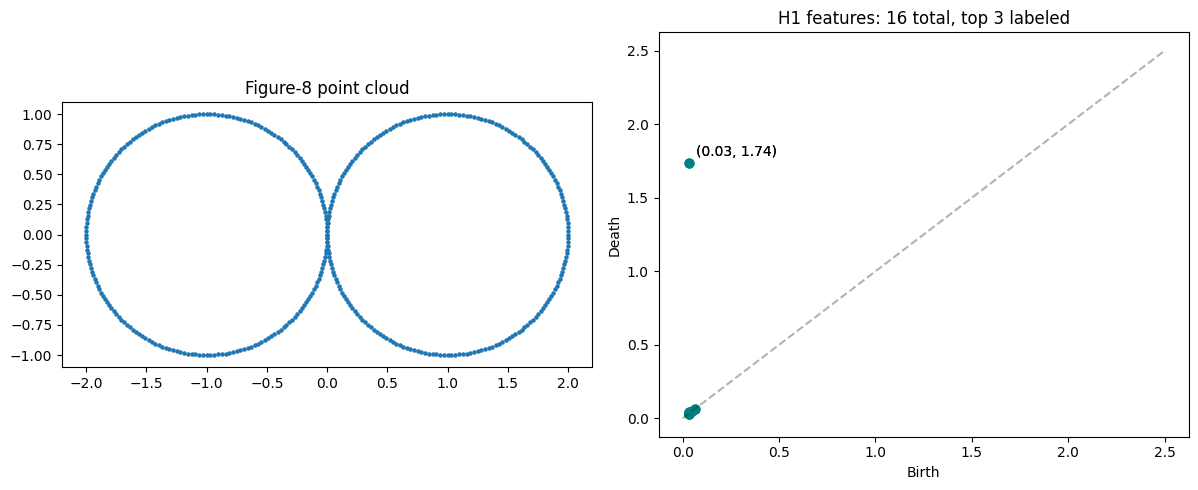

In [4]:
n = 200
theta = np.linspace(0, 2 * np.pi, n, endpoint=False)

# Left circle centered at (-1, 0)
left = np.stack([np.cos(theta) - 1, np.sin(theta)], axis=1)
# Right circle centered at (1, 0)
right = np.stack([np.cos(theta) + 1, np.sin(theta)], axis=1)
figure8 = np.vstack([left, right])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(figure8[:, 0], figure8[:, 1], s=5)
axes[0].set_aspect("equal")
axes[0].set_title("Figure-8 point cloud")

diag = vr.fit_transform(figure8[None, ...])[0]
h1 = diag[diag[:, 2] == 1]
persistence = h1[:, 1] - h1[:, 0]
top_idx = persistence.argsort()[-5:][::-1]

axes[1].scatter(h1[:, 0], h1[:, 1], c="teal", s=40)
axes[1].plot([0, 2.5], [0, 2.5], "k--", alpha=0.3)
axes[1].set_xlabel("Birth")
axes[1].set_ylabel("Death")
for j in range(min(2, len(top_idx))):
    b, d = h1[top_idx[j], 0], h1[top_idx[j], 1]
    axes[1].annotate(f"({b:.2f}, {d:.2f})", (b, d), textcoords="offset points", xytext=(5, 5))
axes[1].set_title(f"H1 features: {len(h1)} total, top {min(3, len(top_idx))} labeled")

plt.tight_layout()
plt.show()



## Exercise 4: Annulus (thick ring) vs thin circle

Sample 200 points from a thin circle (radius 1, no thickness) vs 200 points from a fat annulus (inner radius 0.7, outer radius 1.3).

**Predict before running:** Both have one loop (H1). Which has longer persistence — the thin circle or the fat annulus? Think about what "birth" and "death" depend on: point spacing (affects birth) and the width/fill of the ring (affects death).

**My prediction:** The annulus' H1 will have an earlier death because its radius is 0.7 < 1, the radius of the circle. I also suspect the persistence will be smaller because the thicker the annulus, the harder it will be to distinguish between it and a filled circle.



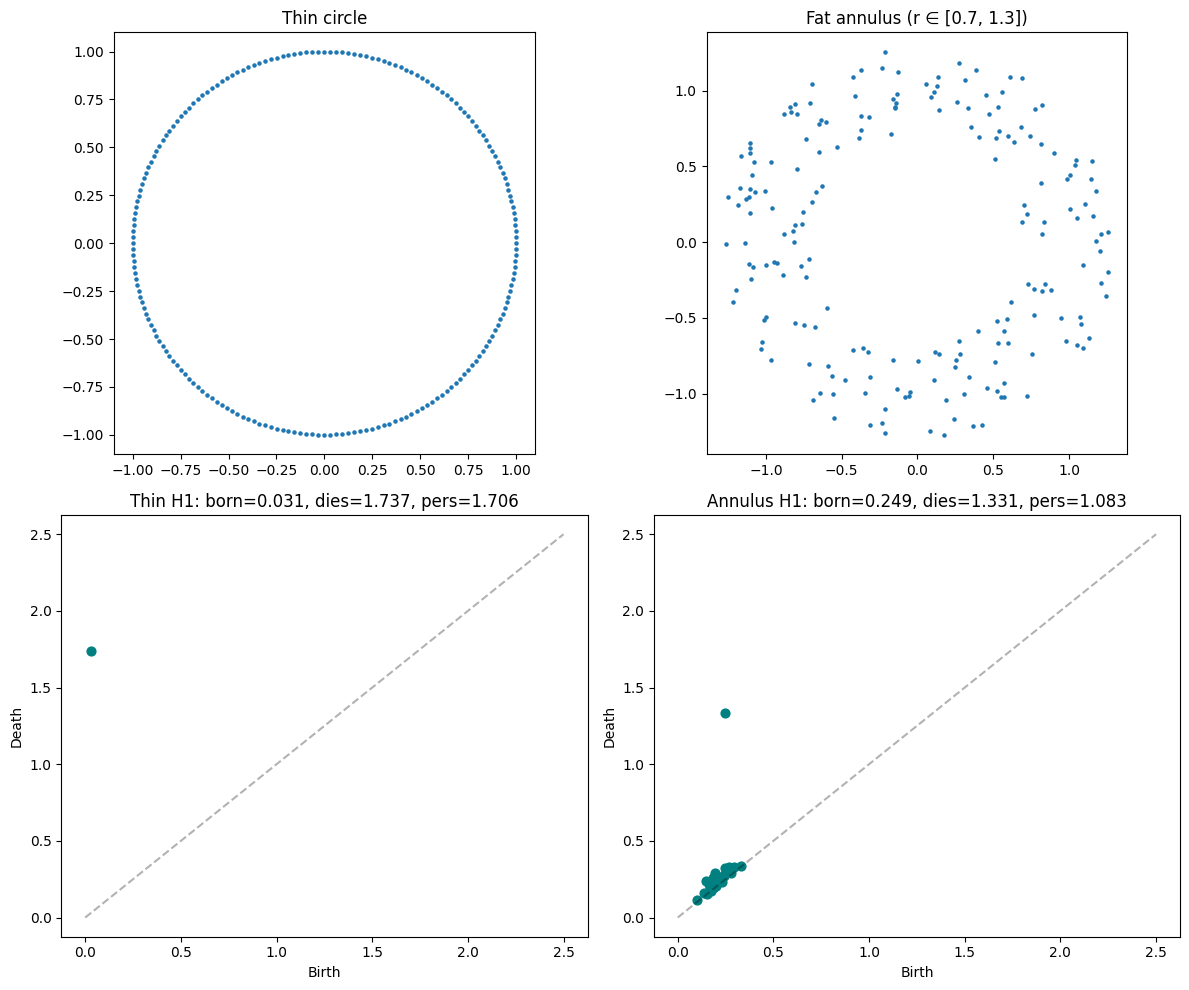

In [5]:
np.random.seed(7)
n = 200

# Thin circle
theta_thin = np.linspace(0, 2 * np.pi, n, endpoint=False)
thin_circle = np.stack([np.cos(theta_thin), np.sin(theta_thin)], axis=1)

# Fat annulus: uniform in polar between r=0.7 and r=1.3
theta_fat = np.random.uniform(0, 2 * np.pi, n)
r_fat = np.sqrt(np.random.uniform(0.7**2, 1.3**2, n))  # sqrt for uniform area sampling
annulus = np.stack([r_fat * np.cos(theta_fat), r_fat * np.sin(theta_fat)], axis=1)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].scatter(thin_circle[:, 0], thin_circle[:, 1], s=5)
axes[0, 0].set_aspect("equal")
axes[0, 0].set_title("Thin circle")

axes[0, 1].scatter(annulus[:, 0], annulus[:, 1], s=5)
axes[0, 1].set_aspect("equal")
axes[0, 1].set_title("Fat annulus (r ∈ [0.7, 1.3])")

for idx, (pts, label) in enumerate([(thin_circle, "Thin"), (annulus, "Annulus")]):
    diag = vr.fit_transform(pts[None, ...])[0]
    h1 = diag[diag[:, 2] == 1]
    persistence = h1[:, 1] - h1[:, 0]
    max_i = persistence.argmax()
    axes[1, idx].scatter(h1[:, 0], h1[:, 1], c="teal", s=40)
    axes[1, idx].plot([0, 2.5], [0, 2.5], "k--", alpha=0.3)
    axes[1, idx].set_xlabel("Birth")
    axes[1, idx].set_ylabel("Death")
    b, d = h1[max_i, 0], h1[max_i, 1]
    axes[1, idx].set_title(f"{label} H1: born={b:.3f}, dies={d:.3f}, pers={d-b:.3f}")

plt.tight_layout()
plt.show()


## Exercise 5: Random noise baseline

200 points uniformly distributed in a unit square. No structure.

**Predict before running:** Will there be any H1 features? If so, will they be persistent (far from diagonal) or short-lived (hugging the diagonal)? This is your "null hypothesis" — what does a persistence diagram look like when there's *nothing* to find?

**My prediction:** I expect to see a few connected components, coalescing into one connected component. If there are H1 features, they'll be short-lived.


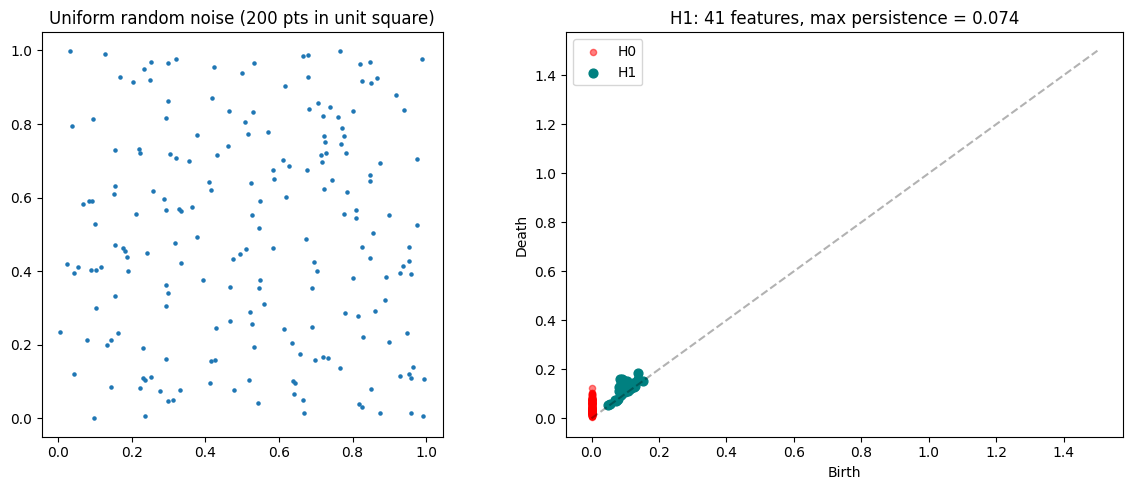

In [6]:
np.random.seed(99)
noise = np.random.uniform(0, 1, size=(200, 2))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(noise[:, 0], noise[:, 1], s=5)
axes[0].set_aspect("equal")
axes[0].set_title("Uniform random noise (200 pts in unit square)")

diag = vr.fit_transform(noise[None, ...])[0]
h1 = diag[diag[:, 2] == 1]
h0 = diag[diag[:, 2] == 0]

axes[1].scatter(h0[:, 0], h0[:, 1], c="red", s=20, alpha=0.5, label="H0")
axes[1].scatter(h1[:, 0], h1[:, 1], c="teal", s=40, label="H1")
axes[1].plot([0, 1.5], [0, 1.5], "k--", alpha=0.3)
axes[1].set_xlabel("Birth")
axes[1].set_ylabel("Death")
axes[1].legend()

if len(h1) > 0:
    persistence = h1[:, 1] - h1[:, 0]
    axes[1].set_title(f"H1: {len(h1)} features, max persistence = {persistence.max():.3f}")
else:
    axes[1].set_title("No H1 features")

plt.tight_layout()
plt.show()


## Debrief

After running all five exercises, note:

1. **Exercise 1:** H1 birth time _increases_ as gap size increases. The persistence (death − birth) _decreases_.
2. **Exercise 2:** H0 death time tracks the _separation_ between clusters.
3. **Exercise 3:** Two loops → _2_ H1 features. They have _same_ birth/death because _they have the same radii_.
4. **Exercise 4:** The thin circle has _greater_ persistence than the annulus because _don't know_.
5. **Exercise 5:** Random noise produces H1 features that are _short-lived_ (persistent / short-lived). This means any "real" signal needs persistence greater than _1_ to be distinguishable from noise.

**Key takeaway for the real experiment:** When we ablate a class from CLIP embeddings, we're looking for a change in persistence that exceeds the noise floor established by Exercise 5's pattern (many short-lived features near the diagonal).

## Building H1 / H2 intuition: sphere vs torus in R^3

Two classic shapes with known homology:

- **Unit sphere** $S^2 \subset \mathbb{R}^3$: $H_0 = 1$, $H_1 = 0$, $H_2 = 1$ (one void, no loops).
- **Torus** $T^2 \subset \mathbb{R}^3$: $H_0 = 1$, $H_1 = 2$ (two independent loops — through the hole and around the tube), $H_2 = 1$ (the enclosed void).

If the pipeline is working, the sphere's diagram should show one persistent H2 feature and *no* persistent H1; the torus's diagram should show two persistent H1 features and one persistent H2.

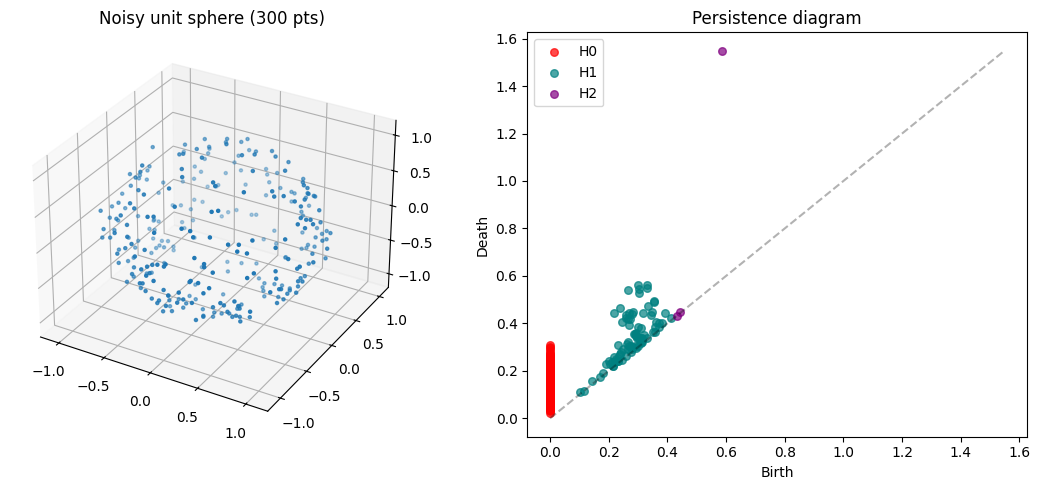

In [7]:
# Noisy unit sphere in R^3
np.random.seed(0)
n_sphere = 300
sphere = np.random.randn(n_sphere, 3)
sphere = sphere / np.linalg.norm(sphere, axis=1, keepdims=True)
sphere = sphere + 0.05 * np.random.randn(n_sphere, 3)  # radial noise

vr_h2 = VietorisRipsPersistence(homology_dimensions=[0, 1, 2], n_jobs=-1)
diag_sphere = vr_h2.fit_transform(sphere[None, ...])[0]

fig = plt.figure(figsize=(11, 5))

ax0 = fig.add_subplot(1, 2, 1, projection="3d")
ax0.scatter(sphere[:, 0], sphere[:, 1], sphere[:, 2], s=5)
ax0.set_title(f"Noisy unit sphere ({n_sphere} pts)")

ax1 = fig.add_subplot(1, 2, 2)
colors = {0: "red", 1: "teal", 2: "purple"}
labels = {0: "H0", 1: "H1", 2: "H2"}
for dim in [0, 1, 2]:
    pts = diag_sphere[diag_sphere[:, 2] == dim]
    ax1.scatter(pts[:, 0], pts[:, 1], c=colors[dim], s=30, alpha=0.7, label=labels[dim])
lim = diag_sphere[:, 1].max()
ax1.plot([0, lim], [0, lim], "k--", alpha=0.3)
ax1.set_xlabel("Birth"); ax1.set_ylabel("Death")
ax1.set_title("Persistence diagram")
ax1.legend()

plt.tight_layout()
plt.show()

VR persistence: 100%|██████████| 3/3 [06:12<00:00, 124.26s/it]


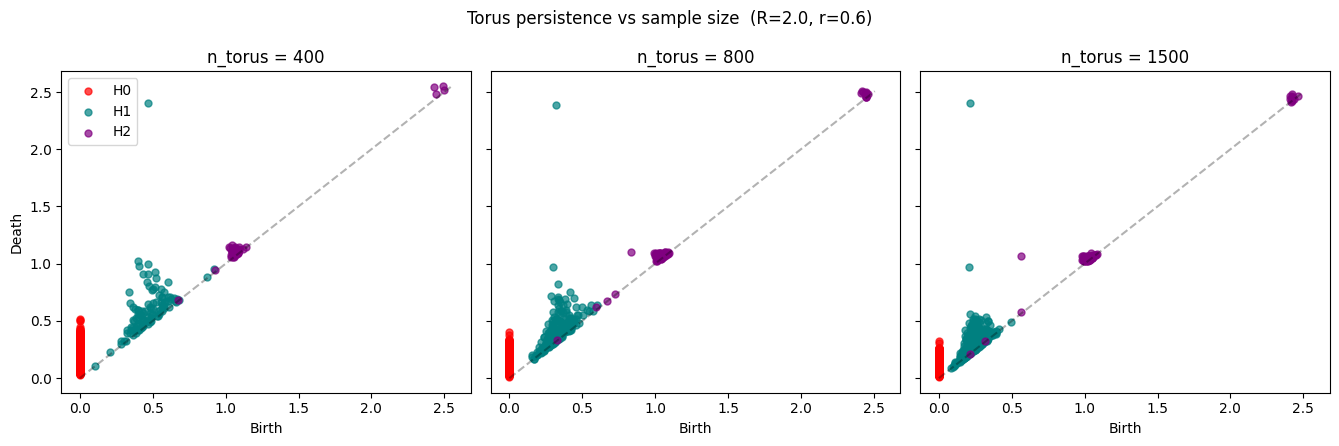

In [8]:
# Noisy genus-1 torus in R^3: fix (R, r), vary n_torus to see how density
# affects the persistence diagram — H2 in particular needs dense sampling.
from tqdm.auto import tqdm

R, r = 2.0, 0.6
n_torus_values = [400, 800, 1500]
noise_std = 0.03

def sample_torus(n, R, r, noise_std, seed):
    rng = np.random.default_rng(seed)
    u = rng.uniform(0, 2 * np.pi, n)
    v = rng.uniform(0, 2 * np.pi, n)
    pts = np.stack([
        (R + r * np.cos(v)) * np.cos(u),
        (R + r * np.cos(v)) * np.sin(u),
        r * np.sin(v),
    ], axis=1)
    return pts + noise_std * rng.standard_normal(pts.shape)

# Compute persistence up-front with a progress bar (VR with H2 on 2500 pts is slow).
diagrams = {}
for n in tqdm(n_torus_values, desc="VR persistence"):
    pts = sample_torus(n, R, r, noise_std, seed=1)
    diagrams[n] = vr_h2.fit_transform(pts[None, ...])[0]

colors = {0: "red", 1: "teal", 2: "purple"}
labels = {0: "H0", 1: "H1", 2: "H2"}

fig, axes = plt.subplots(1, len(n_torus_values), figsize=(4.5 * len(n_torus_values), 4.5),
                         sharex=True, sharey=True)

for ax, n in zip(axes, n_torus_values):
    diag = diagrams[n]
    for dim in [0, 1, 2]:
        d = diag[diag[:, 2] == dim]
        ax.scatter(d[:, 0], d[:, 1], c=colors[dim], s=25, alpha=0.7, label=labels[dim])

    lim = diag[:, 1].max()
    ax.plot([0, lim], [0, lim], "k--", alpha=0.3)
    ax.set_title(f"n_torus = {n}")
    ax.set_xlabel("Birth")

axes[0].set_ylabel("Death")
axes[0].legend(loc="upper left")
fig.suptitle(f"Torus persistence vs sample size  (R={R}, r={r})")
plt.tight_layout()
plt.show()

### Takeaways:

1. The two H1 features should look different. The torus has two independent 1-loops: the big one through the donut hole (length $2\pi R \approx 12.6$) and the small one around the tube (length $2\pi r \approx 3.8$). They die at different scales — the small loop dies around $\sim r = 0.6$, the big loop around $\sim R = 2.0$. If you only see one persistent teal point near death=2.5 it's the big loop; the small loop's death is much earlier and easy to miss in the H1 noise cloud near the diagonal. Worth re-checking — that's a more sensitive H1 test than "any persistent H1 at all."
2. The density requirement isn't arbitrary — Niyogi–Smale–Weinberger gives roughly $n \gtrsim \text{surface area} / \text{reach}^2$. Here surface_area $= 4\pi^2 R r \approx 47$, reach $= r = 0.6$, so the floor for reliable recovery is around 1000–1500. That's exactly where you saw H2 stabilize. Not a coincidence.
3. Calibration for the real experiment — and this is the part that should actually shift your priors for the CLIP/CIFAR-100 work: detecting H2 needed ~1500 points on a 2D surface in $\R^3$ with reach 0.6. The CIFAR embeddings live in $\R^{512}$, the "manifold" (if there is one) has unknown reach but almost certainly much smaller than the inter-cluster distances, and the brief caps you at ~2000 stratified points. H1 is plausibly detectable; H2 is almost certainly not. I'd update toward "only report H0/H1 changes in Phase 3, don't even compute H2 on the real embeddings" — saves compute and avoids reading noise as signal.

### Some extra theory:

#### Reach (Federer, 1959)
For a closed subset $M \subset \mathbb{R}^d$, define the medial axis as

$$\mathrm{Med}(M) = {x \in \mathbb{R}^d \setminus M : \text{the nearest-point projection } \pi_M(x) \text{ is not unique}}.$$

The reach is the distance from $M$ to its medial axis:

$$\tau(M) = \inf_{p \in M,\ x \in \mathrm{Med}(M)} |p - x|.$$

Equivalently: $\tau(M)$ is the largest $r$ such that every point within distance $r$ of $M$ has a unique closest point on $M$.

Geometric meaning for a smooth submanifold: $1/\tau$ upper-bounds both the maximum principal curvature and the inverse of the bottleneck distance (closest approach of two non-adjacent sheets of $M$). It penalizes whichever is worse — sharp local curvature or near-self-contact.

Examples:
- Sphere of radius $R$: $\tau = R$.
- Torus with major $R$, minor $r$ ($R > r$): $\tau = \min(r,, R - r)$. For $R=2, r=0.6$: $\tau = 0.6$ (tube curvature wins).
- Affine subspace: $\tau = \infty$.
- Two parallel planes distance $2d$ apart: $\tau = d$ (the medial axis is the midplane).

#### Niyogi–Smale–Weinberger (2008)
Finding the Homology of Submanifolds with High Confidence from Random Samples, Discrete & Computational Geometry 39(1–3).

Setup. Let $M \subset \mathbb{R}^d$ be a compact $k$-dimensional $C^2$ submanifold with reach $\tau > 0$ and volume $V$. Let $X = {x_1, \ldots, x_n}$ be sampled i.i.d. from the uniform distribution on $M$.

Theorem 3.1 (informal). Fix $\varepsilon \in \big(0,, \tau\sqrt{3/5},/,2\big)$ and $\delta \in (0,1)$. If

$$n ;\geq; \beta_1 \Big( \log \beta_2 ;+; \log(1/\delta) \Big),$$

where

$$\beta_1 = \frac{V}{(\cos^k \theta_1), \mathrm{vol}(B^k_{\varepsilon/4})}, \qquad \beta_2 = \frac{V}{(\cos^k \theta_2), \mathrm{vol}(B^k_{\varepsilon/8})},$$

$\theta_1 = \arcsin!\big(\tfrac{\varepsilon}{8\tau}\big),\ \theta_2 = \arcsin!\big(\tfrac{\varepsilon}{16\tau}\big)$, and $B^k_r$ is a Euclidean $k$-ball of radius $r$, then with probability $\geq 1 - \delta$ the offset

$$U_\varepsilon ;=; \bigcup_{i=1}^n B(x_i,, \varepsilon)$$

deformation-retracts onto $M$. In particular $H_\bullet(U_\varepsilon) \cong H_\bullet(M)$.

The scaling that matters. Dropping constants and log factors:

$$\boxed{,n ;\gtrsim; \frac{V}{\varepsilon^k},}, \qquad \text{with } \varepsilon \lesssim \tau.$$

So to detect features at the manifold's own length scale you need

$$n ;\gtrsim; \frac{V}{\tau^k}.$$

For the torus with $R=2, r=0.6$: $V = 4\pi^2 R r \approx 47$, $k=2$, $\tau = 0.6$, giving the order-of-magnitude floor $n \gtrsim 47/0.36 \approx 130$ for the existence of a covering radius that works, with the actual sample count inflated by the constants and logs — empirically landing in the 1000–1500 range, matching what we saw.

Two caveats specific to our setting.

- NSW is about the Čech complex on the offset $U_\varepsilon$, not Vietoris–Rips. VR sandwiches Čech: $\mathrm{Cech}\varepsilon \subseteq \mathrm{VR}\varepsilon \subseteq \mathrm{Cech}_{\varepsilon\sqrt{2k/(k+1)}}$. So the conclusion transfers up to a small filtration-scale distortion, but exact birth/death times shift.
NSW assumes noiseless samples on $M$. Robust extensions (Niyogi–Smale–Weinberger 2011, "A topological view of unsupervised learning from noisy data") replace reach with the condition number of the noise model and tighten the bound, but the scaling form is the same.
- The practical upshot for the CIFAR experiment is the one I flagged before: in $\mathbb{R}^{512}$ with unknown (likely small) reach and $k$ unknown but plausibly $\geq 10$, the $V/\tau^k$ floor is enormous — you cannot reach it with the 2000-point budget the brief allows, which is why H2 on CLIP embeddings is essentially unrecoverable here even in principle.

#### Intuitive picture of reach

The rolling-ball definition. Imagine you have a marble of radius $r$, and you try to place it anywhere in space — not on the surface. For each spot you place it, ask: "what's the closest point on the surface?" The reach $\tau$ is the largest $r$ for which that question always has a unique answer, no matter where you put the marble.

Equivalently: roll a marble of radius $\tau$ around the outside (and inside) of your shape. As long as it only ever touches the shape at one point, you're fine. The reach is the largest radius for which that's true.

Two ways the reach can be small:

- Sharp curvature. If your surface bulges with curvature $1/r$ somewhere, a marble bigger than $r$ placed snugly against that bulge has two closest points (or wraps around). Reach $\leq r$.
- Near self-contact (bottleneck). If two distant parts of the surface come within distance $2d$ of each other, a marble of radius $> d$ placed midway between them has two closest points — one on each sheet. Reach $\leq d$.

The reach is whichever of these is worse. It's a single number that says "this is the smallest length scale at which the shape stops looking locally flat."

Examples worked out:
- Sphere of radius $R$. A marble inside the sphere fits perfectly when it has radius $R$; bigger and it doesn't fit. Outside, the sphere is convex so any marble works. Reach $= R$.
- Torus, major $R$, minor $r$, with $R > r$. Two failure modes:
    - Inside the tube, curvature is $1/r$ → marble bigger than $r$ won't fit. ($\tau \leq r$.)
    - The central donut hole has width $2(R-r)$ → a marble of radius $R-r$ placed in the middle touches the torus at two opposite points. ($\tau \leq R-r$.)
    - So $\tau = \min(r,\ R-r)$. For our $R=2, r=0.6$: $\tau = \min(0.6,\ 1.4) = 0.6$.
- Flat plane. No curvature, no bottleneck. $\tau = \infty$.
- Two parallel planes $2d$ apart. Bottleneck distance $d$. $\tau = d$.
- A shape with a corner or cusp. Curvature is infinite at the corner → $\tau = 0$. (Reach requires $C^2$ smoothness to be positive.)

The slogan: *reach is the radius of the largest tube you can wrap around the shape without the tube self-intersecting.*

#### Niyogi–Smale–Weinberger (cleaned up)

Setup. $M$ is a compact $k$-dimensional smooth submanifold of $\mathbb{R}^d$ with reach $\tau > 0$ and $k$-dimensional volume $V$. Sample $n$ points i.i.d. uniformly from $M$.

Theorem (informal). Pick a scale $\varepsilon$ smaller than about $\tau/2$, and a failure probability $\delta$. If

$$n \geq \beta_1 \cdot \big( \log \beta_2 + \log(1/\delta) \big)$$

then with probability at least $1 - \delta$, the union of balls

$$U_\varepsilon = \bigcup_{i=1}^n B(x_i,\ \varepsilon)$$

has the same homology as $M$ itself. The constants $\beta_1, \beta_2$ are explicit but messy; the form that matters is the scaling.

Scaling form. Dropping constants and logs:

$$n \gtrsim \frac{V}{\varepsilon^k}, \qquad \text{with } \varepsilon \lesssim \tau.$$

Intuition for why this scaling. To "see" the shape from a point cloud, the balls of radius $\varepsilon$ around your samples must 
- (a) cover the whole surface, and 
- (b) not be so big they fill in the actual holes. 

Condition (b) forces $\varepsilon < \tau$ (a ball larger than the reach starts bridging the bottleneck or wrapping the curvature). Condition (a) forces you to have roughly $V / \varepsilon^k$ samples — that's just "how many $k$-dimensional patches of size $\varepsilon$ fit on a surface of $k$-volume $V$."

Plug in $\varepsilon = \tau$ to get the cleanest version:

$$n \gtrsim \frac{V}{\tau^k}.$$

Applied to our torus. $V = 4\pi^2 R r \approx 47$, $\tau = 0.6$, $k = 2$, so the order-of-magnitude floor is $n \gtrsim 47/0.36 \approx 130$ — which is the bare-minimum scaling; the actual constants and logs push that into the 1000+ range, matching where you saw H2 stabilize.

Why this is grim for CLIP embeddings. In $\mathbb{R}^{512}$, the intrinsic $k$ is unknown but plausibly $\geq 10$, and $\tau$ is unknown but bounded by inter-cluster distances (likely small). $V/\tau^k$ grows astronomically in $k$ — the curse of dimensionality applied to topology. With $n \approx 2000$ you're nowhere near the floor, which is why H2 on real embeddings won't be meaningfully recoverable.